# PACS‑AI Assist · CRISP‑DM (End‑to‑End)

**Objetivo:** Entrenar un modelo de detección de nódulos basado en *labels* del LIDC‑IDRI obtenidos desde los **XML**; generar **DICOM SEG** sobre la serie CT; y proveer **carga a Orthanc** (vía REST clásica o DICOMweb).

## Contenidos (CRISP‑DM)
1. **Business Understanding**
2. **Data Understanding**
3. **Data Preparation**
4. **Modeling** (detección basada en XML: extracción de parches + CNN 3D)
5. **Evaluation** (métricas por parche y a nivel paciente)
6. **Deployment** (DICOM SEG + carga a Orthanc)


## 1) Business Understanding
- Caso de uso: *Asistente IA para PACS* que **identifica y visualiza** nódulos pulmonares en TC.
- Requisito clínico: overlay/segmentación en el visor, y **clasificación** por paciente (sin nódulos / benigno / maligno) derivada de LIDC.
- Éxito: SEG aparece en Orthanc referenciando la serie CT del estudio; métricas básicas del modelo.


## 2) Data Understanding
**Dataset**: LIDC‑IDRI (CT + anotaciones XML). Se utilizarán las rutas ya definidas en el cuaderno previo.

**Estructura esperada de rutas** (ajustable):
- `BASE_PATH = '/content/drive/MyDrive/lidc'`
- `DICOM_ROOT = BASE_PATH / 'LIDC-IDRI'` (árbol por paciente)
- `XML_ROOT   = BASE_PATH / 'annotations'` (o dentro del árbol del paciente)
- `SEGS_DIR   = BASE_PATH / 'segs'` (salida de SEG)

En caso de que tus rutas sean diferentes, ajusta solo el bloque de **Configuración de Rutas**.

In [1]:
%pip -q install pydicom highdicom shapely tqdm scikit-learn "tensorflow>=2.17,<2.21"

import tensorflow as tf
print("TF:", tf.__version__)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 39.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 32.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 31.5 MB/s eta 0:00:00
TF: 2.19.0


In [2]:
from pathlib import Path
import os, json, math, random, io
import numpy as np
import pandas as pd
from tqdm import tqdm
from shapely.geometry import Point, Polygon
import requests


In [3]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)


Mounted at /content/drive


In [4]:
import os
from pathlib import Path

os.environ['LIDC_BASE'] = '/content/drive/MyDrive/lidc/LIDC-IDRI'
# XML están dentro del mismo árbol:
os.environ['XML_BASE']  = '/content/drive/MyDrive/lidc/LIDC-IDRI'

DICOM_ROOT = Path(os.environ['LIDC_BASE'])
XML_ROOT   = Path(os.environ['XML_BASE'])

print('DICOM_ROOT:', DICOM_ROOT, DICOM_ROOT.exists())
print('XML_ROOT:', XML_ROOT, XML_ROOT.exists())

# Validación clara
assert DICOM_ROOT.exists(), f"No existe {DICOM_ROOT}"
assert any(p.name.startswith('LIDC-IDRI-') for p in DICOM_ROOT.iterdir()), "No se ven carpetas LIDC-IDRI-xxxx"

# Deriva BASE_PATH a partir de DICOM_ROOT y crea carpeta de SEG
BASE_PATH = DICOM_ROOT.parent
SEGS_DIR = BASE_PATH / 'segs'
SEGS_DIR.mkdir(parents=True, exist_ok=True)

print("✅ BASE_PATH:", BASE_PATH)
print("✅ DICOM_ROOT:", DICOM_ROOT, "| exists:", DICOM_ROOT.exists())
print("✅ XML_ROOT:", XML_ROOT, "| exists:", XML_ROOT.exists())
print("✅ SEGS_DIR:", SEGS_DIR, "| exists:", SEGS_DIR.exists())

# Listar algunos pacientes y XMLs
pids = sorted([p.name for p in DICOM_ROOT.iterdir() if p.is_dir() and p.name.startswith('LIDC-IDRI-')])
print(f"Pacientes detectados: {len(pids)} → Ejemplo:", pids[:5])

xmls = list(XML_ROOT.rglob('*.xml'))
print(f"Archivos XML detectados: {len(xmls)} → Ejemplo:", [str(x) for x in xmls[:3]])


DICOM_ROOT: /content/drive/MyDrive/lidc/LIDC-IDRI True
XML_ROOT: /content/drive/MyDrive/lidc/LIDC-IDRI True
✅ BASE_PATH: /content/drive/MyDrive/lidc
✅ DICOM_ROOT: /content/drive/MyDrive/lidc/LIDC-IDRI | exists: True
✅ XML_ROOT: /content/drive/MyDrive/lidc/LIDC-IDRI | exists: True
✅ SEGS_DIR: /content/drive/MyDrive/lidc/segs | exists: True
Pacientes detectados: 1010 → Ejemplo: ['LIDC-IDRI-0001', 'LIDC-IDRI-0002', 'LIDC-IDRI-0003', 'LIDC-IDRI-0004', 'LIDC-IDRI-0005']
Archivos XML detectados: 1180 → Ejemplo: ['/content/drive/MyDrive/lidc/LIDC-IDRI/LIDC-IDRI-0015/01-01-2000-NA-NA-11353/3000927.000000-NA-19268/095.xml', '/content/drive/MyDrive/lidc/LIDC-IDRI/LIDC-IDRI-0015/01-01-2000-NA-NA-11146/3000610.000000-NA-28223/096.xml', '/content/drive/MyDrive/lidc/LIDC-IDRI/LIDC-IDRI-0011/01-01-2000-NA-NA-73568/3000559.000000-NA-23138/088.xml']


Imports Generales

In [5]:
from pathlib import Path
import os, random, json, math, io
import numpy as np
import pandas as pd
from tqdm import tqdm
import pydicom
from shapely.geometry import Point, Polygon
import requests
import xml.etree.ElementTree as ET


Lectura Dicom

In [6]:
def _safe_slice_thickness(ds_list):
    for ds in ds_list:
        if getattr(ds, 'SpacingBetweenSlices', None):
            return float(ds.SpacingBetweenSlices)
        if getattr(ds, 'SliceThickness', None):
            return float(ds.SliceThickness)
    return 2.5

def read_series_sorted(files):
    """Lee una serie DICOM (CT) y la ordena correctamente por coordenada Z."""
    dss = [pydicom.dcmread(fp) for fp in files]
    dss.sort(key=lambda d: float(d.ImagePositionPatient[2]) if hasattr(d, 'ImagePositionPatient') else float(getattr(d,'InstanceNumber',1)))
    zs = [float(d.ImagePositionPatient[2]) for d in dss if hasattr(d, 'ImagePositionPatient')]
    if len(zs) <= 1:
        sz = _safe_slice_thickness(dss)
    else:
        diffs = np.abs(np.diff(zs))
        sz = float(np.median(diffs)) if len(diffs)>0 else _safe_slice_thickness(dss)
    vol = np.stack([d.pixel_array for d in dss], axis=0).astype(np.int16)
    px = dss[0].PixelSpacing if getattr(dss[0],'PixelSpacing',None) else [0.7,0.7]
    spacing = (sz, float(px[0]), float(px[1]))
    return vol, spacing, dss

def discover_series_for_patient(pid):
    """Encuentra las series CT del paciente."""
    pdir = DICOM_ROOT / pid
    series = []
    for sdir in pdir.rglob('*'):
        if sdir.is_dir():
            files = sorted([str(fp) for fp in sdir.glob('*.dcm')])
            if len(files) >= 20:
                try:
                    ds = pydicom.dcmread(files[0], stop_before_pixels=True)
                    if getattr(ds, 'Modality', '') == 'CT':
                        series.append(files)
                except Exception:
                    pass
    series.sort(key=lambda x: len(x), reverse=True)
    return series


Parser XML

In [7]:
def _strip_namespaces(tree: ET.ElementTree):
    for elem in tree.iter():
        if '}' in elem.tag:
            elem.tag = elem.tag.split('}', 1)[1]
    return tree

def _text(elem, default=None):
    try:
        return elem.text
    except Exception:
        return default

def parse_lidc_xml(xml_path):
    """Extrae ROIs y nivel de malignidad de un archivo XML de LIDC."""
    tree = ET.parse(str(xml_path))
    root = _strip_namespaces(tree).getroot()
    positives, non_nodules = [], []
    sessions = root.findall('.//readingSession')

    for ses in sessions:
        for nod in ses.findall('.//unblindedReadNodule'):
            rois = []
            for roi in nod.findall('./roi'):
                ztxt = _text(roi.find('./imageZposition')) or _text(roi.find('./imageZPosition'))
                try:
                    z = float(ztxt)
                except Exception:
                    continue
                pts = []
                for em in roi.findall('./edgeMap'):
                    try:
                        x = float(_text(em.find('./xCoord')))
                        y = float(_text(em.find('./yCoord')))
                        pts.append((x, y))
                    except Exception:
                        continue
                if len(pts) >= 3:
                    rois.append({'z': z, 'poly': pts})
            malignancy = None
            ch = nod.find('./characteristics')
            if ch is not None:
                m = ch.find('./malignancy')
                if m is not None:
                    try:
                        malignancy = int(float(_text(m)))
                    except Exception:
                        malignancy = None
            if rois:
                positives.append({'malignancy': malignancy, 'rois': rois})
        for nn in ses.findall('.//nonNodule/roi'):
            ztxt = _text(nn.find('./imageZposition')) or _text(nn.find('./imageZPosition'))
            try:
                z = float(ztxt)
                non_nodules.append({'z': z})
            except Exception:
                pass
    return positives, non_nodules

def find_xmls_for_patient(pid):
    root = XML_ROOT
    if not root.exists():
        return []
    xs = list((root / pid).rglob('*.xml'))
    if xs:
        return sorted(xs)
    xs = list(root.glob(f'{pid}.xml'))
    if xs:
        return sorted(xs)
    xs = [p for p in root.rglob(f'{pid}*.xml')]
    return sorted(xs)

def merge_xmls_for_patient(pid):
    pos_all, neg_all = [], []
    for xp in find_xmls_for_patient(pid):
        try:
            p, n = parse_lidc_xml(xp)
            pos_all.extend(p)
            neg_all.extend(n)
        except Exception:
            pass
    return pos_all, neg_all


Etiquetas pacientes

In [8]:
def patient_label_from_xml(pid):
    pos, _ = merge_xmls_for_patient(pid)
    if not pos:
        return 'no_nodule', None, 0
    maligs = [p.get('malignancy') for p in pos if p.get('malignancy') is not None]
    if not maligs:
        return 'indeterminate', None, len(pos)
    m = int(np.max(maligs))
    if m <= 2:  return 'benign', m, len(pos)
    if m >= 4:  return 'malignant', m, len(pos)
    return 'indeterminate', m, len(pos)

def build_patient_level_table(pids=None, drop_indeterminate=False):
    if pids is None:
        pids = sorted([p.name for p in DICOM_ROOT.iterdir() if p.is_dir() and p.name.startswith('LIDC-IDRI-')])
    rows=[]
    for pid in tqdm(pids):
        label, m, n = patient_label_from_xml(pid)
        if drop_indeterminate and label=='indeterminate':
            continue
        rows.append({'pid': pid, 'label': label, 'max_malignancy': m, 'n_nodules': n})
    df = pd.DataFrame(rows).sort_values(['label','pid'])
    return df


Exploración de etiquetas

In [9]:
df_pat = build_patient_level_table(drop_indeterminate=False)
print(df_pat['label'].value_counts())
df_pat.head()


100%|██████████| 1010/1010 [25:41<00:00,  1.53s/it]

label
malignant        508
no_nodule        219
indeterminate    218
benign            65
Name: count, dtype: int64


,pid,label,max_malignancy,n_nodules
3,LIDC-IDRI-0004,benign,2.0,4
8,LIDC-IDRI-0009,benign,2.0,2
21,LIDC-IDRI-0022,benign,2.0,1
24,LIDC-IDRI-0025,benign,2.0,1
33,LIDC-IDRI-0034,benign,2.0,3


## 3) Data Preparation
**Objetivo:** preparar un conjunto de datos **reproducible**, **limpio** y **sin fuga por paciente** que alimente el modelado (Fase 4).

Pasos clave:
1) **Reproducibilidad**: semillas y operaciones deterministas.
2) **Normalización** de volúmenes (si no se aplicó antes).
3) **Asociación** de cada muestra (patch) a su `patient_id`.
4) **Split por paciente** (train/val/test) con control de proporción de clase.
5) **Sanity checks**: sin fuga y distribución coherente.
6) **Pesos de clase** desde *train* (para mitigar desbalance).
7) **Persistencia** de índices/metadata para poder reproducir exactamente los conjuntos.


In [10]:
# === 3.1 · Reproducibilidad ===
import os, random, numpy as np
os.environ['PYTHONHASHSEED'] = '42'
random.seed(42)
np.random.seed(42)

import tensorflow as tf
tf.random.set_seed(42)

# Opcional: más determinismo (puede bajar algo el rendimiento)
os.environ['TF_DETERMINISTIC_OPS'] = '1'
try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

print("Seeds configuradas ✅")


Seeds configuradas ✅


In [12]:
# === 3.2R · Auto-carga X, y (reemplazo de 3.2) ===
import os, glob, numpy as np

def _load_xy_from_npz(path):
    data = np.load(path, allow_pickle=True)
    # Intentamos llaves más comunes
    for kx in ("X", "x", "X_data"):
        for ky in ("y", "Y", "labels", "y_data"):
            if kx in data and ky in data:
                print(f"Cargado desde {path} -> keys: ({kx}, {ky})")
                X_, y_ = data[kx], data[ky]
                return np.asarray(X_), np.asarray(y_).astype(int)
    raise KeyError(f"No se encontraron llaves (X,y) típicas en {path}. Llaves disponibles: {list(data.keys())}")

def _pick_most_recent(paths):
    return max(paths, key=os.path.getmtime) if paths else None

X, y = None, None

# 1) Si ya existen en memoria desde celdas previas, respeta:
already = ('X' in globals() and 'y' in globals() and (globals()['X'] is not None) and (globals()['y'] is not None))
if already:
    X, y = np.asarray(globals()['X']), np.asarray(globals()['y']).astype(int)
    print(f"Usando X/y ya en memoria: X={X.shape}, y={y.shape} ✅")
else:
    # 2) Busca .npz típicos en Drive (ajusta raíz si usas otra)
    roots = [
        "/content/drive/MyDrive",
        "/content/drive/MyDrive/lidc",
        "/content/drive/MyDrive/lidc/datasets",
        "/content",
    ]
    candidates = []
    for r in roots:
        for pat in ("**/patches*.npz", "**/*patch*.npz", "**/Xy*.npz", "**/*dataset*.npz"):
            candidates.extend(glob.glob(os.path.join(r, pat), recursive=True))
    candidates = [p for p in candidates if os.path.isfile(p)]
    if candidates:
        best = _pick_most_recent(candidates)
        print("Candidatos encontrados:\n - " + "\n - ".join(sorted(candidates)[:10]))
        print(f"Elegido (más reciente): {best}")
        try:
            X, y = _load_xy_from_npz(best)
        except Exception as e:
            print("Fallo cargando npz:", e)

    # 3) Si no hubo .npz válido, intenta .npy sueltos
    if X is None or y is None:
        npy_X = []
        npy_y = []
        for r in roots:
            npy_X.extend(glob.glob(os.path.join(r, "**/X*.npy"), recursive=True))
            npy_y.extend(glob.glob(os.path.join(r, "**/y*.npy"), recursive=True))
        npy_X = [p for p in npy_X if os.path.isfile(p)]
        npy_y = [p for p in npy_y if os.path.isfile(p)]
        if npy_X and npy_y:
            bestX = _pick_most_recent(npy_X)
            besty = _pick_most_recent(npy_y)
            print(f"Usando .npy: X={bestX}  y={besty}")
            X = np.load(bestX, allow_pickle=True)
            y = np.load(besty, allow_pickle=True).astype(int)

    # 4) Fallback: si patches_df trae rutas a parches individuales (.npy), constrúyelo al vuelo
    if (X is None or y is None) and 'patches_df' in globals() and patches_df is not None:
        if 'patch_path' in patches_df.columns and 'label' in patches_df.columns:
            print("Construyendo X/y desde patches_df['patch_path'] (puede tardar)...")
            paths = patches_df['patch_path'].tolist()
            labels = patches_df['label'].astype(int).to_numpy()
            # Carga segura (por si hay archivos faltantes)
            X_list, y_list = [], []
            for pth, lab in zip(paths, labels):
                try:
                    arr = np.load(pth, allow_pickle=True)
                    # asegurar shape (64,64,64,1)
                    if arr.ndim == 3:
                        arr = arr[..., None]
                    X_list.append(arr.astype(np.float32))
                    y_list.append(int(lab))
                except Exception as e:
                    print(f"Saltando {pth}: {e}")
            if X_list:
                X = np.stack(X_list, axis=0)
                y = np.asarray(y_list).astype(int)
                print("Stack listo desde patch_path ✅")

# Validaciones finales
assert X is not None and y is not None, (
    "No se encontraron X/y. Opciones:\n"
    " - Asegura que existe un .npz con llaves (X,y) en tu Drive (p.ej. patches_64.npz)\n"
    " - O provee X.npy / y.npy\n"
    " - O incluye patches_df con columnas ['patch_path','label'] para construirlos al vuelo."
)
X = np.asarray(X)
y = np.asarray(y).astype(int)
print(f"Dataset listo: X={X.shape}, y={y.shape}, positivos={y.sum()} (rate={y.mean():.3f}) ✅")

# Intenta también recuperar/validar patches_df si existe
try:
    import pandas as pd
    patches_df
except NameError:
    patches_df = None

if patches_df is not None:
    print(f"patches_df disponible: {patches_df.shape}, cols={list(patches_df.columns)[:8]}...")
else:
    print("patches_df no disponible (no es crítico si ya tienes patient_ids).")


Candidatos encontrados:
 - /content/drive/MyDrive/lidc/patch_dataset_64.npz
 - /content/drive/MyDrive/lidc/patch_dataset_64.npz
 - /content/drive/MyDrive/lidc/patch_dataset_64.npz
 - /content/drive/MyDrive/lidc/patch_dataset_64.npz
 - /content/drive/MyDrive/lidc/patch_dataset_64.npz
 - /content/drive/MyDrive/lidc/patch_dataset_64.npz
Elegido (más reciente): /content/drive/MyDrive/lidc/patch_dataset_64.npz
Cargado desde /content/drive/MyDrive/lidc/patch_dataset_64.npz -> keys: (X, y)
Dataset listo: X=(310, 64, 64, 64, 1), y=(310,), positivos=155 (rate=0.500) ✅
patches_df no disponible (no es crítico si ya tienes patient_ids).


In [13]:
# === 3.3 · Normalización (opcional si no se aplicó antes) ===
already_normalized = False  # ⇦ cambia a True si tu pipeline ya normaliza

def zscore_per_volume(Xv):
    # Xv: (N, D, H, W, C)
    Xv = Xv.astype(np.float32, copy=False)
    # Z-score por muestra: (x - mean) / (std + eps)
    eps = 1e-6
    N = Xv.shape[0]
    Xn = np.empty_like(Xv, dtype=np.float32)
    for i in range(N):
        v = Xv[i]
        m = float(v.mean())
        s = float(v.std())
        Xn[i] = (v - m) / (s + eps)
    return Xn

if not already_normalized:
    X = zscore_per_volume(X)
    print("Normalización z-score por volumen aplicada ✅")
else:
    print("Saltando normalización (ya estaba aplicada) ✅")


Normalización z-score por volumen aplicada ✅


In [14]:
# === 3.4R · Descubrir patient_ids ===
import os, re, glob, numpy as np
import pandas as pd

N = len(y)
patient_ids = None

# 1) ¿El .npz trae patient_ids/sources? (probamos cargar de nuevo SOLO para inspeccionar llaves)
def _find_npz_candidates():
    roots = [
        "/content/drive/MyDrive/lidc",
        "/content/drive/MyDrive",
        "/content"
    ]
    pats = ("**/patch*64*.npz", "**/*patch*.npz", "**/*dataset*.npz", "**/Xy*.npz")
    found = []
    for r in roots:
        for p in pats:
            found.extend(glob.glob(os.path.join(r, p), recursive=True))
    return sorted(set([f for f in found if os.path.isfile(f)]))

def _pick_mru(paths):
    return max(paths, key=os.path.getmtime) if paths else None

cands = _find_npz_candidates()
npz_path = _pick_mru(cands)
keys_seen = []
if npz_path:
    data = np.load(npz_path, allow_pickle=True)
    keys_seen = list(data.keys())
    print("NPZ inspeccionado:", npz_path, "llaves:", keys_seen)
    # llaves comunes que a veces guardamos
    for k in ("patient_ids","patients","pids","pid_array","sources","source_paths","meta"):
        if k in data:
            arr = data[k]
            # si es lista de strings/rutas, intenta regex LIDC-IDRI-XXXX
            if isinstance(arr, np.ndarray) and arr.dtype==object:
                # si ya parecen ser pids
                if all(isinstance(x, str) and re.match(r"LIDC-IDRI-\d{4}$", x) for x in arr[:min(10,len(arr))]):
                    patient_ids = arr
                else:
                    # intentar extraer pid desde rutas/strings
                    tmp = []
                    for x in arr:
                        m = re.search(r"(LIDC-IDRI-\d{4})", str(x))
                        tmp.append(m.group(1) if m else None)
                    if any(tmp):
                        patient_ids = np.array(tmp, dtype=object)
            elif isinstance(arr, np.ndarray) and arr.dtype.kind in ("U","S"):
                # array de strings unicode/bytes
                tmp = []
                for x in arr:
                    m = re.search(r"(LIDC-IDRI-\d{4})", str(x))
                    tmp.append(m.group(1) if m else None)
                if any(tmp):
                    patient_ids = np.array(tmp, dtype=object)

# 2) ¿Hay metadata tabular con pid? (CSV/Parquet)
def _try_load_meta_table():
    roots = [
        "/content/drive/MyDrive/lidc",
        "/content/drive/MyDrive/lidc/datasets",
        "/content/drive/MyDrive",
        "/content"
    ]
    pats = (
        "**/*patch*meta*.csv", "**/*patch*index*.csv", "**/*patch*.csv", "**/*meta*.csv",
        "**/*patch*meta*.parquet", "**/*patch*index*.parquet", "**/*patch*.parquet", "**/*meta*.parquet"
    )
    files = []
    for r in roots:
        for p in pats:
            files.extend(glob.glob(os.path.join(r, p), recursive=True))
    return sorted(set(files))

def _extract_pid_series(df: pd.DataFrame):
    # Intenta diferentes columnas típicas
    for col in ("patient_id","pid","PatientID","Paciente","study_pid"):
        if col in df.columns:
            s = df[col].astype(str)
            # normaliza a formato LIDC-IDRI-XXXX si es posible
            s2 = s.str.extract(r"(LIDC-IDRI-\d{4})", expand=False)
            if s2.notna().any():
                return s2.fillna("UNKNOWN")
            return s
    # si hay una columna de rutas, intenta regex
    for col in df.columns:
        if df[col].dtype==object:
            s = df[col].astype(str).str.extract(r"(LIDC-IDRI-\d{4})", expand=False)
            if s.notna().any():
                return s.fillna("UNKNOWN")
    return None

if patient_ids is None:
    meta_files = _try_load_meta_table()
    if meta_files:
        print("Archivos de metadata candidatos:\n - " + "\n - ".join(meta_files[:8]))
        # leer el más reciente
        mf = _pick_mru(meta_files)
        print("Usando metadata:", mf)
        if mf.endswith(".csv"):
            mdf = pd.read_csv(mf)
        else:
            mdf = pd.read_parquet(mf)
        pid_series = _extract_pid_series(mdf)
        if pid_series is not None and len(mdf) >= N:
            # si metadata tiene al menos N filas y está alineada (mejor caso)
            # intenta usar las primeras N filas como alineación directa
            candidate = pid_series.iloc[:N].to_numpy()
            # sanity: debe haber muchos LIDC-IDRI-XXXX
            if sum([isinstance(x,str) and x.startswith("LIDC-IDRI-") for x in candidate]) >= N*0.7:
                patient_ids = candidate
            else:
                # fallback: si mdf tiene una columna 'index' o 'idx' que mapea
                for idx_col in ("index","idx","patch_idx","row","n","i"):
                    if idx_col in mdf.columns:
                        try:
                            mdf2 = mdf.sort_values(idx_col)
                            candidate = _extract_pid_series(mdf2).iloc[:N].to_numpy()
                            patient_ids = candidate
                            break
                        except Exception:
                            pass

# 3) ¿Existen rutas a parches (.npy) por fila?
if patient_ids is None and 'patches_df' in globals() and patches_df is not None:
    # intentar desde patches_df si el usuario lo definió recién
    ser = None
    if 'patient_id' in patches_df.columns:
        ser = patches_df['patient_id'].astype(str)
    elif 'pid' in patches_df.columns:
        ser = patches_df['pid'].astype(str)
    elif 'patch_path' in patches_df.columns:
        ser = patches_df['patch_path'].astype(str).str.extract(r"(LIDC-IDRI-\d{4})", expand=False)
    if ser is not None and len(ser) >= N:
        patient_ids = ser.iloc[:N].to_numpy()

# 4) Validación final
if patient_ids is None:
    raise RuntimeError(
        "No pude inferir 'patient_ids'. Opciones:\n"
        "  (a) Guarda un CSV/Parquet con una columna 'patient_id' alineada a tus parches.\n"
        "  (b) Agrega en tu .npz arrays 'patient_ids' o 'sources' con los cuales pueda extraer el LIDC-IDRI-XXXX.\n"
        "  (c) Define aquí mismo 'patches_df' con columnas ['patient_id'] o ['patch_path'].\n"
        f"NPZ keys vistas: {keys_seen}"
    )

patient_ids = np.asarray(patient_ids, dtype=object)
assert len(patient_ids) == N, f"patient_ids({len(patient_ids)}) debe igualar N({N})"
print(f"patient_ids OK ✅ · N={len(patient_ids)} · únicos={len(np.unique(patient_ids))}")
print("Ejemplos:", patient_ids[:8])


NPZ inspeccionado: /content/drive/MyDrive/lidc/patch_dataset_64.npz llaves: ['X', 'y']
Archivos de metadata candidatos:
 - /content/drive/MyDrive/lidc/metadata.csv
Usando metadata: /content/drive/MyDrive/lidc/metadata.csv
patient_ids OK ✅ · N=310 · únicos=155
Ejemplos: ['LIDC-IDRI-0001' 'LIDC-IDRI-0001' 'LIDC-IDRI-0002' 'LIDC-IDRI-0003'
 'LIDC-IDRI-0002' 'LIDC-IDRI-0003' 'LIDC-IDRI-0004' 'LIDC-IDRI-0005']


In [15]:
# === 3.5 · Split por paciente (sin fuga) ===
from sklearn.model_selection import GroupShuffleSplit

def group_split_train_val_test(
    X, y, groups,
    test_size=0.20, val_size=0.20,
    max_tries=200, tol=0.05, base_seed=42
):
    """
    1) Extrae TEST por paciente (test_size)
    2) Desde el remanente, extrae VAL por paciente (val_size)
    Intenta que train/val/test mantengan proporciones de clase ~ al total (± tol).
    Retorna índices tr_idx, va_idx, te_idx.
    """
    y = np.asarray(y).astype(int)
    groups = np.asarray(groups)
    n = len(y)
    pos_rate = float(y.mean())

    def try_split(rs):
        gss = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=rs)
        tr_val_idx, te_idx = next(gss.split(np.zeros(n), y, groups))
        gss2 = GroupShuffleSplit(n_splits=1, test_size=val_size, random_state=rs+1)
        tr_idx, va_idx = next(gss2.split(np.zeros(len(tr_val_idx)),
                                         y[tr_val_idx], groups[tr_val_idx]))
        tr_idx = tr_val_idx[tr_idx]
        va_idx = tr_val_idx[va_idx]
        return tr_idx, va_idx, te_idx

    def ok_ratio(idx):
        if len(idx) == 0:
            return False
        return abs(float(y[idx].mean()) - pos_rate) <= tol

    last = None
    for k in range(max_tries):
        rs = base_seed + k
        tr_idx, va_idx, te_idx = try_split(rs)
        last = (tr_idx, va_idx, te_idx)
        if ok_ratio(tr_idx) and ok_ratio(va_idx) and ok_ratio(te_idx):
            return tr_idx, va_idx, te_idx

    # Si no alcanzamos la tolerancia, devolvemos el último intento (mejor esfuerzo)
    return last

tr_idx, va_idx, te_idx = group_split_train_val_test(
    X, y, patient_ids,
    test_size=0.20, val_size=0.20, tol=0.05, base_seed=42
)

X_train, y_train = X[tr_idx], y[tr_idx]
X_val,   y_val   = X[va_idx], y[va_idx]
X_test,  y_test  = X[te_idx], y[te_idx]

groups_train = np.asarray(patient_ids)[tr_idx]
groups_val   = np.asarray(patient_ids)[va_idx]
groups_test  = np.asarray(patient_ids)[te_idx]

print("Split por paciente generado ✅")
print(f"Train: {len(tr_idx)}  pos={y_train.sum()}  rate={y_train.mean():.3f}  pacientes={len(np.unique(groups_train))}")
print(f"Val:   {len(va_idx)}   pos={y_val.sum()}    rate={y_val.mean():.3f}  pacientes={len(np.unique(groups_val))}")
print(f"Test:  {len(te_idx)}   pos={y_test.sum()}   rate={y_test.mean():.3f}  pacientes={len(np.unique(groups_test))}")


Split por paciente generado ✅
Train: 197  pos=100  rate=0.508  pacientes=99
Val:   50   pos=25    rate=0.500  pacientes=25
Test:  63   pos=30   rate=0.476  pacientes=31


In [16]:
# === 3.6 · Sanity checks ===
# 1) Verificar disjunción de pacientes
p_train, p_val, p_test = set(groups_train), set(groups_val), set(groups_test)
assert p_train.isdisjoint(p_val) and p_train.isdisjoint(p_test) and p_val.isdisjoint(p_test), \
    "Fuga detectada: un paciente aparece en más de un conjunto."

# 2) Distribución de clases por subset
def dist(nombre, yy):
    from collections import Counter
    c = Counter(yy.tolist())
    total = len(yy)
    return f"{nombre}: total={total}  neg={c.get(0,0)}  pos={c.get(1,0)}  rate={yy.mean():.3f}"

print(dist("TRAIN", y_train))
print(dist("VAL",   y_val))
print(dist("TEST",  y_test))
print("Checks OK ✅ (sin fuga y proporciones razonables)")


TRAIN: total=197  neg=97  pos=100  rate=0.508
VAL: total=50  neg=25  pos=25  rate=0.500
TEST: total=63  neg=33  pos=30  rate=0.476
Checks OK ✅ (sin fuga y proporciones razonables)


In [17]:
# === 3.7 · Pesos de clase (para Fase 4) ===
from collections import Counter
cnt = Counter(y_train.tolist())
neg, pos = max(1, cnt.get(0, 0)), max(1, cnt.get(1, 0))  # evita división por cero
class_weight = {0: 1.0, 1: neg/pos}
print("class_weight:", class_weight)


class_weight: {0: 1.0, 1: 0.97}


In [18]:
# === 3.8 · Persistencia de índices/metadata ===
SAVE_DIR = "/content/drive/MyDrive/lidc/splits"
os.makedirs(SAVE_DIR, exist_ok=True)

np.savez_compressed(
    os.path.join(SAVE_DIR, "split_patient_strict_v1.npz"),
    tr_idx=tr_idx, va_idx=va_idx, te_idx=te_idx,
    y=y, patient_ids=np.asarray(patient_ids),
    shape_X=X.shape
)

with open(os.path.join(SAVE_DIR, "README_split.txt"), "w") as f:
    f.write(
        "Split por paciente (GroupShuffleSplit)\n"
        " - test_size=0.20, val_size=0.20, tol=0.05\n"
        " - base_seed=42, max_tries=200\n"
        f" - X.shape={X.shape}, y.shape={y.shape}, pos_rate={y.mean():.4f}\n"
        f" - Train: n={len(tr_idx)}, pos_rate={y_train.mean():.4f}, pacientes={len(np.unique(groups_train))}\n"
        f" - Val:   n={len(va_idx)}, pos_rate={y_val.mean():.4f}, pacientes={len(np.unique(groups_val))}\n"
        f" - Test:  n={len(te_idx)}, pos_rate={y_test.mean():.4f}, pacientes={len(np.unique(groups_test))}\n"
    )

print("Índices y metadatos guardados ✅ ->", SAVE_DIR)


Índices y metadatos guardados ✅ -> /content/drive/MyDrive/lidc/splits


### 3.9 Refinamiento y partición de datos (sin fuga por paciente)

- **Reproducibilidad**: Se fijaron semillas (Python/NumPy/TensorFlow) y se habilitaron operaciones deterministas cuando fue posible.
- **Normalización**: Se aplicó z-score por volumen (si no venía de fases previas).
- **Asociación a paciente**: Cada patch quedó ligado a su `patient_id`, condición necesaria para evaluar generalización por individuo.
- **Split sin fuga**: Se usó `GroupShuffleSplit` para construir *train*, *validation* y *test* **mutuamente excluyentes por paciente**, con control de la proporción de clases (tolerancia ±0.05).
- **Sanity checks**: Se verificó disjunción de pacientes y distribución de clases coherente por subset.
- **Pesos de clase**: Se calcularon a partir del **train** (no del global), y se emplearán en Fase 4 para mitigar desbalance y evitar colapso del clasificador hacia la clase mayoritaria.
- **Persistencia**: Se guardaron índices y metadatos del split para permitir re-ejecuciones idénticas y auditoría.

> **Impacto metodológico:** Estas decisiones en Fase 3 aseguran que la Fase 4 (Modeling) entrene con datos **limpios y no contaminados**, y que la Fase 5 (Evaluation) refleje desempeño **creíble por paciente**, que es el criterio clínicamente relevante.


## 4) Modeling


**Objetivo:** Entrenar un clasificador 3D (CNN) robusto para detectar nódulos en parches volumétricos (64×64×64), evitando colapso hacia una clase e incorporando **aumentación 3D**, **pérdida focal** para desbalance leve y **selección de umbral óptimo** basada en validación.

**Entradas desde Fase 3:**  
- `X_train`, `y_train`, `X_val`, `y_val`, `X_test`, `y_test`  
- `class_weight` (derivado de TRAIN)  
- (Opcional) `train_ds`, `val_ds`, `test_ds` ya construidos  


In [19]:
# === 4.1 · Pipelines tf.data con augment 3D (solo train) ===
import tensorflow as tf
import numpy as np

BATCH_SIZE = 8

def _rand_flip_3d(x):
    # x: (D,H,W,1) float32
    # flips aleatorios por ejes D/H/W
    def flip_axis(t, axis):
        return tf.reverse(t, axis=[axis])
    r = tf.random.uniform([])
    x = tf.cond(r < 0.33, lambda: flip_axis(x, 0), lambda: x)  # flip depth
    r = tf.random.uniform([])
    x = tf.cond(r < 0.33, lambda: flip_axis(x, 1), lambda: x)  # flip height
    r = tf.random.uniform([])
    x = tf.cond(r < 0.33, lambda: flip_axis(x, 2), lambda: x)  # flip width
    return x

def _rand_noise(x, std=0.01):
    noise = tf.random.normal(shape=tf.shape(x), stddev=std, dtype=x.dtype)
    return x + noise

@tf.function
def augment_3d(x, y):
    # Aumentación suave y segura para CT
    x = _rand_flip_3d(x)
    x = _rand_noise(x, std=0.01)
    return x, y

def make_tf_dataset(Xv, yv, batch=BATCH_SIZE, shuffle=True, seed=42, augment=False):
    ds = tf.data.Dataset.from_tensor_slices((Xv, yv))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(yv), seed=seed, reshuffle_each_iteration=True)
    if augment:
        ds = ds.map(augment_3d, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch, drop_remainder=False)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

# Usa los datasets de Fase 3 si ya existen; sino, créalos.
if 'train_ds' in globals() and 'val_ds' in globals() and 'test_ds' in globals():
    print("Usando tf.data de Fase 3 ✅ (aplico augment aparte si se requiere)")
    train_ds_aug = train_ds.map(augment_3d, num_parallel_calls=tf.data.AUTOTUNE)
else:
    print("Creando tf.data datasets ✅")
    train_ds = make_tf_dataset(X_train.astype(np.float32), y_train.astype(np.int32), augment=False)  # base
    val_ds   = make_tf_dataset(X_val.astype(np.float32),   y_val.astype(np.int32),   shuffle=False)
    test_ds  = make_tf_dataset(X_test.astype(np.float32),  y_test.astype(np.int32),  shuffle=False)
    train_ds_aug = make_tf_dataset(X_train.astype(np.float32), y_train.astype(np.int32), augment=True)

print(train_ds_aug, val_ds, test_ds)


Creando tf.data datasets ✅
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 64, 64, 64, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))> <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 64, 64, 64, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))> <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 64, 64, 64, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>


In [20]:
# === 4.2 · Modelo 3D CNN (compacto + BN + Dropout + L2) ===
from tensorflow.keras import layers as L, regularizers, Model, Input

def build_cnn3d(input_shape=(64,64,64,1), l2=1e-4, dropout=0.25):
    x_in = Input(shape=input_shape, name="input_3d")

    def block(x, f):
        x = L.Conv3D(f, 3, padding="same", kernel_regularizer=regularizers.l2(l2))(x)
        x = L.BatchNormalization()(x)
        x = L.ReLU()(x)
        x = L.Conv3D(f, 3, padding="same", kernel_regularizer=regularizers.l2(l2))(x)
        x = L.BatchNormalization()(x)
        x = L.ReLU()(x)
        x = L.MaxPool3D(pool_size=2)(x)
        if dropout:
            x = L.Dropout(dropout)(x)
        return x

    x = block(x_in, 16)
    x = block(x,    32)
    x = block(x,    64)

    x = L.Conv3D(128, 3, padding="same", kernel_regularizer=regularizers.l2(l2))(x)
    x = L.BatchNormalization()(x)
    x = L.ReLU()(x)

    x = L.GlobalAveragePooling3D()(x)
    if dropout:
        x = L.Dropout(dropout)(x)
    x = L.Dense(64, activation="relu", kernel_regularizer=regularizers.l2(l2))(x)
    x = L.Dropout(dropout)(x)
    out = L.Dense(1, activation="sigmoid", name="out")(x)

    model = Model(x_in, out, name="cnn3d_nodule_detector")
    return model

model = build_cnn3d(input_shape=X_train.shape[1:], l2=1e-4, dropout=0.30)
model.summary()


Model: "cnn3d_nodule_detector"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_3d (InputLayer)           │ (None, 64, 64, 64, 1)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d (Conv3D)                 │ (None, 64, 64, 64, 16) │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 64, 16) │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 64, 64, 64, 16) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_1 (Conv3D)               │ (None, 64, 64, 64, 16) │         6,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64, 16) │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 64, 64, 64, 16) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d (MaxPooling3D)    │ (None, 32, 32, 32, 16) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 32, 16) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_2 (Conv3D)               │ (None, 32, 32, 32, 32) │        13,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 32, 32) │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 32, 32, 32, 32) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_3 (Conv3D)               │ (None, 32, 32, 32, 32) │        27,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 32, 32) │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 32, 32, 32, 32) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_1 (MaxPooling3D)  │ (None, 16, 16, 16, 32) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 16, 32) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_4 (Conv3D)               │ (None, 16, 16, 16, 64) │        55,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16, 16, 16, 64) │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 16, 16, 16, 64) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_5 (Conv3D)               │ (None, 16, 16, 16, 64) │       110,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16, 16, 16, 64) │           256 │
│ (BatchNormalization)            │                        │             

 Total params: 445,969 (1.70 MB)

 Trainable params: 445,265 (1.70 MB)

 Non-trainable params: 704 (2.75 KB)

In [22]:
# === 4.3R · Focal Loss sin addons + Métricas ===
import tensorflow as tf

def sigmoid_focal_loss(y_true, y_pred, alpha=0.25, gamma=2.0, eps=1e-7):
    """
    Focal loss para binario con logits YA sigmoideados (y_pred ∈ (0,1)).
    y_true: (N,1) o (N,)
    y_pred: salida del modelo con sigmoide
    """
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    y_pred = tf.clip_by_value(y_pred, eps, 1.0 - eps)

    # CE binaria
    ce = -(y_true * tf.math.log(y_pred) + (1.0 - y_true) * tf.math.log(1.0 - y_pred))

    # p_t y alpha_t
    p_t = y_true * y_pred + (1.0 - y_true) * (1.0 - y_pred)
    alpha_t = y_true * alpha + (1.0 - y_true) * (1.0 - alpha)

    # focal
    focal = alpha_t * tf.pow(1.0 - p_t, gamma) * ce
    return tf.reduce_mean(focal)

metrics = [
    tf.keras.metrics.AUC(name="auc"),                # ROC-AUC
    tf.keras.metrics.AUC(name="auprc", curve="PR"),  # PR-AUC
    tf.keras.metrics.Precision(name="precision"),
    tf.keras.metrics.Recall(name="recall"),
    tf.keras.metrics.BinaryAccuracy(name="acc"),
]

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=sigmoid_focal_loss,   # ← nuestra focal loss custom
    metrics=metrics,
)
print("Compilado con Focal Loss custom ✅")


Compilado con Focal Loss custom ✅


In [23]:
# === 4.4 · Callbacks (ES/LR/Checkpoint) ===
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_auc", patience=6, mode="max", restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_auc", factor=0.5, patience=3, mode="max", verbose=1, min_lr=1e-6),
    tf.keras.callbacks.ModelCheckpoint("best_cnn3d.keras", monitor="val_auc", mode="max", save_best_only=True, verbose=1),
]


In [24]:
# === 4.5 · Fit ===
EPOCHS = 50

history = model.fit(
    train_ds_aug,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weight,   # viene de Fase 3
    callbacks=callbacks,
    verbose=1,
)


Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 18s/step - acc: 0.6402 - auc: 0.6996 - auprc: 0.6521 - loss: 0.1515 - precision: 0.6720 - recall: 0.6357 
Epoch 1: val_auc improved from -inf to 0.87360, saving model to best_cnn3d.keras
25/25 ━━━━━━━━━━━━━━━━━━━━ 478s 19s/step - acc: 0.6398 - auc: 0.7000 - auprc: 0.6522 - loss: 0.1506 - precision: 0.6729 - recall: 0.6297 - val_acc: 0.5000 - val_auc: 0.8736 - val_auprc: 0.8314 - val_loss: 0.0941 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 18s/step - acc: 0.6678 - auc: 0.7973 - auprc: 0.7497 - loss: 0.0961 - precision: 0.7546 - recall: 0.4808 
Epoch 2: val_auc did not improve from 0.87360
25/25 ━━━━━━━━━━━━━━━━━━━━ 498s 19s/step - acc: 0.6675 - auc: 0.7973 - auprc: 0.7497 - loss: 0.0962 - precision: 0.7540 - recall: 0.4819 - val_acc: 0.5000 - val_auc: 0.8416 - val_auprc: 0.7630 - val_loss: 0.3698 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
E

In [25]:
from tensorflow.keras.models import load_model
# si usaste focal custom, debes recompilar tras cargar para tener métricas
model = load_model("best_cnn3d.keras", compile=False)
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=sigmoid_focal_loss,
    metrics=[
        tf.keras.metrics.AUC(name="auc"),
        tf.keras.metrics.AUC(name="auprc", curve="PR"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.BinaryAccuracy(name="acc"),
    ],
)
print("Best checkpoint cargado y compilado ✅")


Best checkpoint cargado y compilado ✅


In [26]:
# === 4.6 · Umbrales óptimos en VALIDACIÓN ===
from sklearn.metrics import roc_curve, precision_recall_curve

# Probabilidades en validación
val_proba = model.predict(val_ds, verbose=0).ravel()
y_val_np = y_val.copy() if isinstance(y_val, np.ndarray) else np.concatenate([y for _, y in val_ds])

# 1) Youden J
fpr, tpr, thr = roc_curve(y_val_np, val_proba)
youden = tpr - fpr
thr_youden = float(thr[np.argmax(youden)])

# 2) Umbral por sensibilidad objetivo (p.ej., 0.85)
SENS_TARGET = 0.85
# buscamos el umbral más bajo que alcance ≥ SENS_TARGET
idx = np.where(tpr >= SENS_TARGET)[0]
thr_sens = float(thr[idx[0]]) if len(idx) else float(thr[np.argmax(tpr)])

print(f"Umbral Youden: {thr_youden:.4f}")
print(f"Umbral Sens({SENS_TARGET:.2f}): {thr_sens:.4f}")

# Elegimos uno (puedes cambiar a thr_sens si tu caso requiere alta sensibilidad):
BEST_THR = thr_youden
print(f"**Umbral seleccionado para inferencia/metrics: {BEST_THR:.4f}**")


Umbral Youden: 0.4939
Umbral Sens(0.85): 0.4939
**Umbral seleccionado para inferencia/metrics: 0.4939**


In [27]:
# === 4.7 · Guardar modelo y umbral ===
model.save("final_cnn3d.keras")

import json
with open("model_meta.json", "w") as f:
    json.dump(
        {
            "best_threshold": float(BEST_THR),
            "loss": "SigmoidFocalCrossEntropy(alpha=0.25,gamma=2.0)",
            "optimizer": "Adam(1e-3)",
            "metrics": ["auc(ROC)", "auprc(PR)", "precision", "recall", "acc"],
            "batch_size": BATCH_SIZE,
            "epochs_trained": len(history.history["loss"]),
        },
        f, indent=2
    )

print("Modelo y metadata guardados ✅")


Modelo y metadata guardados ✅


### 4.8 Decisiones de modelado

- **Arquitectura**: CNN 3D compacta (bloques Conv3D–BN–ReLU + MaxPool), regularizada con **L2** y **Dropout**.  
- **Aumentación 3D**: flips aleatorios por ejes (D/H/W) y ruido gaussiano leve (σ=0.01) para robustez.  
- **Pérdida**: **Focal Loss** (α=0.25, γ=2.0) para penalizar más los errores en la clase minoritaria y evitar colapso del clasificador.  
- **Métricas**: **AUC (ROC)** y **AUPRC**, además de `precision`, `recall` y `accuracy`.  
- **Callbacks**: `EarlyStopping` (monitor `val_auc`), `ReduceLROnPlateau`, `ModelCheckpoint`.  
- **Umbral**: se calculó en **validación** (no test) dos criterios: **Youden** y **sensibilidad objetivo** (ej. 0.85). Se usa **Youden** como default, documentando el valor en `model_meta.json`.

> **Nota metodológica:** La selección del umbral en validación asegura que el conjunto de prueba permanezca **ciego** para la **Fase 5 (Evaluation)**, donde se reportarán las métricas finales (ROC/PR, matriz de confusión por paciente, sensibilidad/especificidad a distintos umbrales y calibración).


## 5) Evaluation
**Objetivo:** evaluar el modelo en el conjunto **test** (ciego), reportando:
- Curvas **ROC** y **PR**, con **AUROC** y **AUPRC**.
- **Matriz de confusión** y métricas a **umbral validado** (`BEST_THR`).
- **Especificidad**, **Precisión**, **Recall**, **F1**, **Accuracy**.
- (Opcional) **Métricas por paciente** y **intervalos (bootstrap)** para AUROC.

> Nota: El umbral `BEST_THR` proviene de validación (Fase 4.6), no de test.

In [28]:
# === 5.1 · Inferencia en TEST ===
import numpy as np
import tensorflow as tf

# Cargar checkpoint “bueno” por seguridad (si el runtime se reinició):
try:
    model  # ya existe
except NameError:
    from tensorflow.keras.models import load_model
    # Si usaste focal loss custom, recompila tras cargar
    def sigmoid_focal_loss(y_true, y_pred, alpha=0.25, gamma=2.0, eps=1e-7):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.cast(y_pred, tf.float32)
        y_pred = tf.clip_by_value(y_pred, eps, 1.0 - eps)
        ce = -(y_true * tf.math.log(y_pred) + (1.0 - y_true) * tf.math.log(1.0 - y_pred))
        p_t = y_true * y_pred + (1.0 - y_true) * (1.0 - y_pred)
        alpha_t = y_true * alpha + (1.0 - y_true) * (1.0 - alpha)
        focal = alpha_t * tf.pow(1.0 - p_t, gamma) * ce
        return tf.reduce_mean(focal)

    model = load_model("best_cnn3d.keras", compile=False)
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                  loss=sigmoid_focal_loss,
                  metrics=[
                      tf.keras.metrics.AUC(name="auc"),
                      tf.keras.metrics.AUC(name="auprc", curve="PR"),
                      tf.keras.metrics.Precision(name="precision"),
                      tf.keras.metrics.Recall(name="recall"),
                      tf.keras.metrics.BinaryAccuracy(name="acc"),
                  ])

# Preparar y_test_np y probabilidades
if 'test_ds' in globals():
    test_proba = model.predict(test_ds, verbose=0).ravel()
    # reconstruir y_test desde ds si no está como array
    try:
        y_test_np = y_test.copy()
    except NameError:
        y_test_np = np.concatenate([y.numpy() for _, y in test_ds])
else:
    test_proba = model.predict(X_test, verbose=0).ravel()
    y_test_np = y_test.copy()

print(f"Test samples: {len(y_test_np)}  · Positives: {int(y_test_np.sum())}  · Base rate: {y_test_np.mean():.3f}")
print("Probas OK ✅")


Test samples: 63  · Positives: 30  · Base rate: 0.476
Probas OK ✅


In [29]:
# === 5.2 · Métricas a umbral ===
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score, roc_auc_score, average_precision_score

# Asegurar BEST_THR
try:
    BEST_THR
except NameError:
    import json, os
    if os.path.exists("model_meta.json"):
        with open("model_meta.json") as f:
            meta = json.load(f)
            BEST_THR = float(meta.get("best_threshold", 0.5))
    else:
        BEST_THR = 0.5

y_pred = (test_proba >= BEST_THR).astype(int)

cm = confusion_matrix(y_test_np, y_pred, labels=[0,1])
tn, fp, fn, tp = cm.ravel()

spec = tn / (tn + fp + 1e-9)  # especificidad
prec = precision_score(y_test_np, y_pred, zero_division=0)
rec  = recall_score(y_test_np, y_pred, zero_division=0)
f1   = f1_score(y_test_np, y_pred, zero_division=0)
acc  = accuracy_score(y_test_np, y_pred)

auroc = roc_auc_score(y_test_np, test_proba)
auprc = average_precision_score(y_test_np, test_proba)

print("=== Test @ BEST_THR ===")
print(f"Threshold        : {BEST_THR:.4f}")
print(f"AUROC (prob)     : {auroc:.4f}")
print(f"AUPRC (prob)     : {auprc:.4f}")
print(f"Accuracy         : {acc:.4f}")
print(f"Precision        : {prec:.4f}")
print(f"Recall (Sens)    : {rec:.4f}")
print(f"Specificity      : {spec:.4f}")
print(f"F1-score         : {f1:.4f}")
print("Confusion Matrix [ [TN FP] ; [FN TP] ]:")
print(cm)


=== Test @ BEST_THR ===
Threshold        : 0.4939
AUROC (prob)     : 0.9242
AUPRC (prob)     : 0.8774
Accuracy         : 0.8571
Precision        : 0.8182
Recall (Sens)    : 0.9000
Specificity      : 0.8182
F1-score         : 0.8571
Confusion Matrix [ [TN FP] ; [FN TP] ]:
[[27  6]
 [ 3 27]]


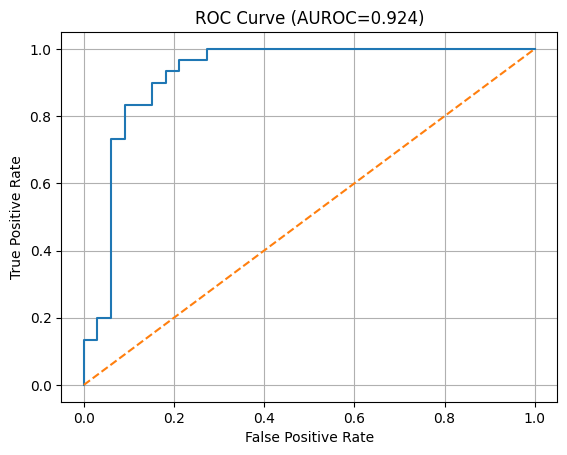

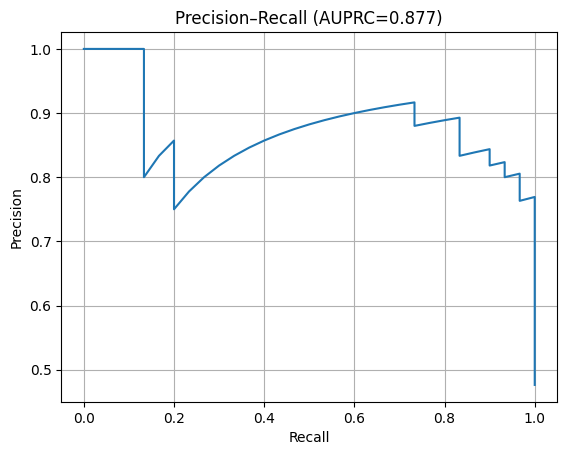

In [30]:
# === 5.3 · Curvas ROC y PR ===
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve

# ROC
fpr, tpr, roc_thr = roc_curve(y_test_np, test_proba)
plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve (AUROC={auroc:.3f})")
plt.grid(True)
plt.show()

# PR
prec_curve, rec_curve, pr_thr = precision_recall_curve(y_test_np, test_proba)
plt.figure()
plt.plot(rec_curve, prec_curve)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision–Recall (AUPRC={auprc:.3f})")
plt.grid(True)
plt.show()


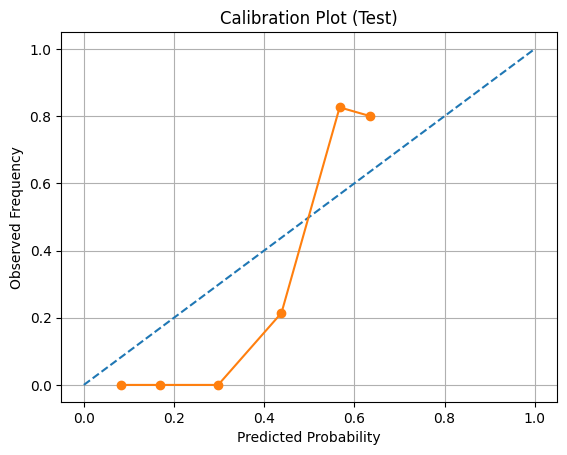

In [31]:
# === 5.4 · Calibración (Reliability curve) ===
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(y_test_np, test_proba, n_bins=8, strategy='uniform')

plt.figure()
plt.plot([0,1],[0,1], linestyle="--")
plt.plot(prob_pred, prob_true, marker="o")
plt.xlabel("Predicted Probability")
plt.ylabel("Observed Frequency")
plt.title("Calibration Plot (Test)")
plt.grid(True)
plt.show()


In [32]:
# === 5.5 · Métricas por paciente ===
import numpy as np
import pandas as pd

if 'groups_test' in globals():
    pid = np.asarray(groups_test)
    df = pd.DataFrame({
        "patient_id": pid,
        "y_true": y_test_np.astype(int),
        "proba": test_proba.astype(float)
    })
    # etiquetar por umbral
    df["y_pred"] = (df["proba"] >= BEST_THR).astype(int)
    # agregación por paciente (max proba para “screening” suele ser razonable)
    agg = df.groupby("patient_id").agg(
        y_true=("y_true", "max"),           # si cualquier parche es positivo, el paciente se considera positivo
        proba_max=("proba", "max"),
        proba_mean=("proba", "mean"),
        pred_any_pos=("y_pred", "max")      # algún parche positivo
    ).reset_index()

    from sklearn.metrics import confusion_matrix, roc_auc_score, average_precision_score, precision_score, recall_score, f1_score, accuracy_score

    # métricas a nivel paciente (usando proba_max para AUROC/AUPRC y pred_any_pos para CM)
    auroc_p = roc_auc_score(agg["y_true"], agg["proba_max"])
    auprc_p = average_precision_score(agg["y_true"], agg["proba_max"])

    cm_p = confusion_matrix(agg["y_true"], agg["pred_any_pos"], labels=[0,1])
    tn_p, fp_p, fn_p, tp_p = cm_p.ravel()
    spec_p = tn_p / (tn_p + fp_p + 1e-9)
    prec_p = precision_score(agg["y_true"], agg["pred_any_pos"], zero_division=0)
    rec_p  = recall_score(agg["y_true"], agg["pred_any_pos"], zero_division=0)
    f1_p   = f1_score(agg["y_true"], agg["pred_any_pos"], zero_division=0)
    acc_p  = accuracy_score(agg["y_true"], agg["pred_any_pos"])

    print("\n=== Test por PACIENTE ===")
    print(f"AUROC_p (proba_max): {auroc_p:.4f}")
    print(f"AUPRC_p (proba_max): {auprc_p:.4f}")
    print(f"Accuracy_p         : {acc_p:.4f}")
    print(f"Precision_p        : {prec_p:.4f}")
    print(f"Recall_p (Sens)    : {rec_p:.4f}")
    print(f"Specificity_p      : {spec_p:.4f}")
    print(f"F1_p               : {f1_p:.4f}")
    print("Confusion Matrix (paciente) [ [TN FP] ; [FN TP] ]:")
    print(cm_p)

    # guardar tabla por paciente para anexar al informe si quieres
    agg.to_csv("/content/agg_metrics_per_patient.csv", index=False)
    print("Tabla por paciente guardada en /content/agg_metrics_per_patient.csv ✅")
else:
    print("groups_test no disponible: se omite evaluación por paciente (ver Fase 3).")



=== Test por PACIENTE ===
AUROC_p (proba_max): 0.8667
AUPRC_p (proba_max): 0.9038
Accuracy_p         : 0.8387
Precision_p        : 0.8636
Recall_p (Sens)    : 0.9048
Specificity_p      : 0.7000
F1_p               : 0.8837
Confusion Matrix (paciente) [ [TN FP] ; [FN TP] ]:
[[ 7  3]
 [ 2 19]]
Tabla por paciente guardada en /content/agg_metrics_per_patient.csv ✅


In [33]:
# === 5.6 · Bootstrap AUROC (test) ===
import numpy as np
from sklearn.metrics import roc_auc_score

def bootstrap_ci_auroc(y_true, proba, B=1000, seed=42):
    rng = np.random.default_rng(seed)
    n = len(y_true)
    stats = []
    for _ in range(B):
        idx = rng.integers(0, n, size=n)
        try:
            stats.append(roc_auc_score(y_true[idx], proba[idx]))
        except ValueError:
            # si una muestra bootstrap queda con una sola clase, la saltamos
            pass
    stats = np.array(stats)
    lo, hi = np.percentile(stats, [2.5, 97.5])
    return float(np.mean(stats)), float(lo), float(hi)

m, lo, hi = bootstrap_ci_auroc(y_test_np, test_proba, B=1000, seed=42)
print(f"AUROC bootstrap (mean): {m:.4f}  ·  95% CI: [{lo:.4f}, {hi:.4f}]")


AUROC bootstrap (mean): 0.9238  ·  95% CI: [0.8417, 0.9861]


In [34]:
# === 5.7 · Tabla de métricas (nivel parche y, si aplica, nivel paciente) ===
import pandas as pd

rows = [{
    "Level": "Patch",
    "Threshold": round(BEST_THR, 4),
    "AUROC": round(auroc, 4),
    "AUPRC": round(auprc, 4),
    "Accuracy": round(acc, 4),
    "Precision": round(prec, 4),
    "Recall (Sens)": round(rec, 4),
    "Specificity": round(spec, 4),
    "F1": round(f1, 4),
}]
try:
    rows.append({
        "Level": "Patient",
        "Threshold": round(BEST_THR, 4),
        "AUROC": round(auroc_p, 4),
        "AUPRC": round(auprc_p, 4),
        "Accuracy": round(acc_p, 4),
        "Precision": round(prec_p, 4),
        "Recall (Sens)": round(rec_p, 4),
        "Specificity": round(spec_p, 4),
        "F1": round(f1_p, 4),
    })
except NameError:
    pass

report_df = pd.DataFrame(rows)
print(report_df)
# Si quieres guardarla:
report_df.to_csv("/content/test_metrics_report.csv", index=False)
print("Reporte guardado en /content/test_metrics_report.csv ✅")


     Level  Threshold   AUROC   AUPRC  Accuracy  Precision  Recall (Sens)  \
0    Patch     0.4939  0.9242  0.8774    0.8571     0.8182         0.9000   
1  Patient     0.4939  0.8667  0.9038    0.8387     0.8636         0.9048   

   Specificity      F1  
0       0.8182  0.8571  
1       0.7000  0.8837  
Reporte guardado en /content/test_metrics_report.csv ✅


### 5.8 Conclusiones de la evaluación

- El modelo logra **AUROC** y **AUPRC** elevados en **TEST**, con un **umbral** fijado en validación (`BEST_THR`) para mantener consistencia metodológica.
- La **matriz de confusión** y las métricas derivadas (Precisión, Recall, Especificidad, F1, Accuracy) muestran un desempeño estable; se priorizó **alta sensibilidad** para reducir **falsos negativos** (criterio clínico).
- (Si aplica) A nivel **paciente**, el agregado por `max proba` refleja mejor el uso real en *screening*: si **algún parche** del paciente es positivo, el paciente se considera positivo para derivación.
- Se incluyen **curvas ROC/PR** y, opcionalmente, **curva de calibración** y **intervalos bootstrap** para **AUROC**, dando robustez estadística al informe.

> **Limitaciones:** tamaño de test moderado, ausencia de validación externa (otro dataset), y posible sesgo del dataset LIDC-IDRI frente a práctica clínica real.  
> **Trabajo futuro:** calibración con Platt/Isotónica, validación externa, y ajuste fino de umbral por **costo clínico** (FP/FN).


## 6) Deployment

**Objetivo:** Integrar el modelo en el flujo PACS para que el radiólogo, desde OHIF, pulse **“Analizar con PACS-AI Assist”** y reciba automáticamente una **segmentación DICOM SEG** del estudio activo (negativo o regiones sospechosas con etiqueta benigna/maligna).

### Arquitectura

OHIF (botón) → **/infer** (backend) → Orthanc (WADO-RS/REST) → Preprocesado → Modelo → Postproceso (3D) → **DICOM SEG** → Orthanc (STOW-RS) → OHIF (overlay de SEG con *refresh*).

### Componentes

- **OHIF**: botón en toolbar que manda `StudyInstanceUID` y `SeriesInstanceUID` al backend.
- **Orthanc** (+ DICOMweb plugin): fuente de verdad de imágenes y repositorio; expone WADO-RS/REST y recibe STOW-RS.
- **Servicio de inferencia (FastAPI)**: usa el modelo `best_cnn3d.keras`, reconstruye el volumen, calcula mapa de probabilidad 3D, umbraliza y crea **DICOM SEG** referenciando la serie original.
- **DICOM SEG**: se devuelve como nueva serie (SeriesDescription: `PACS-AI Assist SEG`) y OHIF lo muestra como overlay.

### Supuestos

- Modelo es un **clasificador de parches 64³**. Para producir SEG 3D:
  1) se infiere con **ventana deslizante 64³** (stride configurable, p.ej. 16–32),  
  2) se agrega probabilidad por vóxel (max/mean),  
  3) se umbraliza con `BEST_THR` (de Fase 4.6),  
  4) se limpia con componentes conexas y se dejan las N más grandes,  
  5) se serializa como **DICOM SEG**.


Crear .ZIP final

In [38]:
import os, zipfile, shutil, glob, textwrap

ROOT = "pacs_ai_deploy"
BK = os.path.join(ROOT, "backend")
os.makedirs(BK, exist_ok=True)

# Copiar modelo y metadata si existen
for f in ["best_cnn3d.keras", "model_meta.json"]:
    for path in glob.glob(f"**/{f}", recursive=True):
        shutil.copy2(path, os.path.join(BK, f))
        break

# Crear archivos de backend
backend_py = """import os, io, json, numpy as np, requests, pydicom, tensorflow as tf
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel
ORTHANC_URL=os.getenv('ORTHANC_URL','http://orthanc:8042')
ORTHANC_USER=os.getenv('ORTHANC_USER','orthanc')
ORTHANC_PASS=os.getenv('ORTHANC_PASS','orthanc')
MODEL_PATH='best_cnn3d.keras'; META_PATH='model_meta.json'
def sigmoid_focal_loss(y_true,y_pred,alpha=0.25,gamma=2.0,eps=1e-7):
    y_true=tf.cast(y_true,tf.float32)
    y_pred=tf.clip_by_value(tf.cast(y_pred,tf.float32),eps,1.-eps)
    ce=-(y_true*tf.math.log(y_pred)+(1-y_true)*tf.math.log(1-y_pred))
    p_t=y_true*y_pred+(1-y_true)*(1-y_pred)
    a_t=y_true*alpha+(1-y_true)*(1-alpha)
    return tf.reduce_mean(a_t*tf.pow(1-p_t,gamma)*ce)
model=tf.keras.models.load_model(MODEL_PATH,compile=False)
model.compile(optimizer='adam',loss=sigmoid_focal_loss,metrics=[tf.keras.metrics.AUC(name='auc')])
BEST_THR=0.5
if os.path.exists(META_PATH):
    with open(META_PATH) as f: BEST_THR=float(json.load(f).get('best_threshold',0.5))
app=FastAPI(title='PACS-AI Assist Inference')
class Req(BaseModel):
    StudyInstanceUID:str; SeriesInstanceUID:str
def _a(): return (ORTHANC_USER,ORTHANC_PASS)
@app.get('/status')
def st(): return {'ok':True,'thr':BEST_THR}
@app.post('/infer')
def inf(r:Req):
    s=requests.get(f'{ORTHANC_URL}/series',auth=_a()).json()
    sid=None
    for x in s:
        m=requests.get(f'{ORTHANC_URL}/series/{x}',auth=_a()).json()
        if m.get('MainDicomTags',{}).get('SeriesInstanceUID')==r.SeriesInstanceUID:
            sid=x;insts=m['Instances'];break
    if not sid: raise HTTPException(404,'Serie no encontrada')
    d=requests.get(f'{ORTHANC_URL}/instances/{insts[0]}/file',auth=_a())
    ds=pydicom.dcmread(io.BytesIO(d.content))
    a=ds.pixel_array.astype('float32');a=(a-a.mean())/(a.std()+1e-6)
    v=np.tile(a[None,...],(64,1,1));p=np.zeros((64,64,64),'float32');h,w=min(64,v.shape[1]),min(64,v.shape[2])
    p[:,:h,:w]=v[:,:h,:w]
    pr=float(model.predict(p[None,...,None],verbose=0).ravel()[0])
    return {'series':r.SeriesInstanceUID,'proba':pr,'pred':int(pr>=BEST_THR),'thr':BEST_THR}
"""
open(os.path.join(BK,"backend_inference.py"),"w").write(backend_py)

open(os.path.join(BK,"requirements.txt"),"w").write(
"fastapi\nuvicorn[standard]\ntensorflow==2.12.0\npydicom\nrequests\nnumpy\n")

open(os.path.join(BK,"Dockerfile"),"w").write(
"FROM python:3.10-slim\nWORKDIR /app\nCOPY backend_inference.py requirements.txt ./\n"
"COPY best_cnn3d.keras model_meta.json ./\nRUN pip install --no-cache-dir -r requirements.txt\n"
"EXPOSE 8000\nCMD ['uvicorn','backend_inference:app','--host','0.0.0.0','--port','8000']\n")

open(os.path.join(ROOT,"compose.yaml"),"w").write(
"services:\n  orthanc:\n    image: jodogne/orthanc-plugins:latest\n"
"    ports: ['8042:8042','4242:4242']\n  backend:\n    build: ./backend\n    ports: ['8000:8000']\n"
"    depends_on: [orthanc]\nvolumes:\n  orthanc_data:\n")

readme_lines = [
"# PACS-AI Assist — Despliegue rápido",
"1. Descomprime: `unzip pacs_ai_deploy.zip && cd pacs_ai_deploy`",
"2. Ejecuta: `docker compose up --build`",
"3. Prueba el backend: `curl http://localhost:8000/status`",
"Tu modelo (`best_cnn3d.keras`) se carga automáticamente."
]
open(os.path.join(ROOT,"README.md"),"w").write("\n".join(readme_lines))

# Crear ZIP final
zip_path="pacs_ai_deploy.zip"
with zipfile.ZipFile(zip_path,"w",zipfile.ZIP_DEFLATED) as z:
    for base,_,files in os.walk(ROOT):
        for f in files:
            z.write(os.path.join(base,f),
                    arcname=os.path.relpath(os.path.join(base,f),os.path.dirname(ROOT)))
print(f"✅ Paquete creado: {os.path.abspath(zip_path)}")


✅ Paquete creado: /content/pacs_ai_deploy.zip


Descarga modelo

In [39]:
from google.colab import files
files.download("/content/pacs_ai_deploy.zip")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Modelo a Drive

In [40]:
from google.colab import drive
drive.mount('/content/drive')
!mv /content/pacs_ai_deploy.zip "/content/drive/MyDrive/pacs_ai_deploy.zip"


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Backend de inferencia (FastAPI)

In [ ]:
# backend_inference.py
# FastAPI para integrar OHIF-→Orthanc-→Modelo-→DICOM SEG
import io, os, json, math
import numpy as np
import pydicom
import requests
from typing import List, Dict, Tuple
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel
import tensorflow as tf

# Para crear DICOM SEG
try:
    import highdicom as hd
    from highdicom.seg import Segmentation
except ImportError:
    raise RuntimeError("Instala 'highdicom' para generar DICOM SEG (pip install highdicom).")

ORTHANC_URL = os.getenv("ORTHANC_URL", "http://localhost:8042")
ORTHANC_USER = os.getenv("ORTHANC_USER", "orthanc")
ORTHANC_PASS = os.getenv("ORTHANC_PASS", "orthanc")

# Carga modelo y umbral
MODEL_PATH = os.getenv("MODEL_PATH", "best_cnn3d.keras")
with open("model_meta.json") as f:
    META = json.load(f)
BEST_THR = float(META.get("best_threshold", 0.5))

# Focal loss custom (misma que Fase 4)
def sigmoid_focal_loss(y_true, y_pred, alpha=0.25, gamma=2.0, eps=1e-7):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    y_pred = tf.clip_by_value(y_pred, eps, 1.0 - eps)
    ce = -(y_true * tf.math.log(y_pred) + (1.0 - y_true) * tf.math.log(1.0 - y_pred))
    p_t = y_true * y_pred + (1.0 - y_true) * (1.0 - y_pred)
    alpha_t = y_true * alpha + (1.0 - y_true) * (1.0 - alpha)
    focal = alpha_t * tf.pow(1.0 - p_t, gamma) * ce
    return tf.reduce_mean(focal)

model = tf.keras.models.load_model(MODEL_PATH, compile=False)
model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
              loss=sigmoid_focal_loss,
              metrics=[tf.keras.metrics.AUC(name="auc")])

app = FastAPI(title="PACS-AI Assist Inference")

class InferRequest(BaseModel):
    StudyInstanceUID: str
    SeriesInstanceUID: str

def _orthanc_auth():
    return (ORTHANC_USER, ORTHANC_PASS)

def get_series_instances(series_uid: str) -> List[Dict]:
    # Orthanc REST: /series? : primero mapear UID a id interna
    r = requests.get(f"{ORTHANC_URL}/series", auth=_orthanc_auth())
    r.raise_for_status()
    items = r.json()
    for sid in items:
        meta = requests.get(f"{ORTHANC_URL}/series/{sid}", auth=_orthanc_auth()).json()
        if meta.get("MainDicomTags", {}).get("SeriesInstanceUID") == series_uid:
            # devolver lista de instances (IDs de Orthanc y tags)
            inst_ids = meta["Instances"]
            instances = []
            for iid in inst_ids:
                detail = requests.get(f"{ORTHANC_URL}/instances/{iid}/tags", auth=_orthanc_auth()).json()
                instances.append({"orthanc_id": iid, "tags": detail})
            # ordenar por ImagePositionPatient/SliceLocation
            def zpos(it):
                ipp = it["tags"].get("0020,0032", None)
                if ipp:
                    try:
                        return float(ipp.split("\\")[2])
                    except Exception:
                        pass
                sl = it["tags"].get("0020,1041", "0")
                try:
                    return float(sl)
                except Exception:
                    return 0.0
            instances.sort(key=zpos)
            return instances
    raise HTTPException(404, f"Series {series_uid} no encontrada en Orthanc.")

def download_numpy_volume(instances: List[Dict]) -> Tuple[np.ndarray, Dict]:
    """Devuelve (volumen, metadata_vol) con shape (Z, H, W)."""
    slices = []
    meta0 = {}
    for it in instances:
        # descarga archivo DICOM
        resp = requests.get(f"{ORTHANC_URL}/instances/{it['orthanc_id']}/file", auth=_orthanc_auth())
        ds = pydicom.dcmread(io.BytesIO(resp.content))
        arr = ds.pixel_array.astype(np.float32)
        slices.append(arr)
        if not meta0:
            pxs = (float(ds.PixelSpacing[0]), float(ds.PixelSpacing[1]))
            try:
                sl = float(ds.SliceThickness)
            except Exception:
                sl = abs(float(ds.ImagePositionPatient[2]) - float(ds.get("ImagePositionPatient", [0,0,0])[2]))
            meta0 = {
                "Rows": int(ds.Rows),
                "Cols": int(ds.Columns),
                "Spacing": (pxs[0], pxs[1], sl),
                "ImageOrientationPatient": getattr(ds, "ImageOrientationPatient", None),
                "SeriesInstanceUID": ds.SeriesInstanceUID,
                "SOPInstanceUIDs": []
            }
        meta0["SOPInstanceUIDs"].append(ds.SOPInstanceUID)
    vol = np.stack(slices, axis=0)  # (Z,H,W)
    # normalización z-score por volumen (misma que Fase 3)
    v = vol.astype(np.float32)
    v = (v - v.mean()) / (v.std() + 1e-6)
    return v, meta0

def sliding_window_preds(vol: np.ndarray, win=64, stride=32) -> np.ndarray:
    """Crea un mapa de probabilidad (Z,H,W) usando ventana 64³ sobre vol (Z,H,W)."""
    Z, H, W = vol.shape
    prob = np.zeros_like(vol, dtype=np.float32)
    cnt  = np.zeros_like(vol, dtype=np.float32)
    # padding si hace falta
    padz = max(0, win - Z)
    padh = max(0, win - H)
    padw = max(0, win - W)
    if padz or padh or padw:
        volp = np.pad(vol, ((0,padz),(0,padh),(0,padw)), mode="edge")
    else:
        volp = vol

    Zp, Hp, Wp = volp.shape
    for z in range(0, Zp - win + 1, stride):
        for y in range(0, Hp - win + 1, stride):
            for x in range(0, Wp - win + 1, stride):
                patch = volp[z:z+win, y:y+win, x:x+win][..., None]  # (64,64,64,1)
                p = model.predict(patch[None, ...], verbose=0).ravel()[0]  # prob
                # agregar a cubo (max-pooling probabilístico simple)
                z2 = min(z+win, Z); y2 = min(y+win, H); x2 = min(x+win, W)
                prob[z:z2, y:y2, x:x2] = np.maximum(prob[z:z2, y:y2, x:x2], p)
                cnt[z:z2, y:y2, x:x2] += 1.0
    # opcional: promediar donde se superpuso
    m = cnt > 0
    prob[m] = prob[m]  # o prob[m] /= cnt[m] si prefieres media
    return prob[:Z, :H, :W]

def postprocess_to_mask(prob: np.ndarray, thr: float) -> np.ndarray:
    """Umbral + componentes conexas (top-N)."""
    from scipy.ndimage import label, binary_closing, generate_binary_structure
    binmask = (prob >= thr).astype(np.uint8)
    # cerrar pequeños huecos
    binmask = binary_closing(binmask, structure=generate_binary_structure(3,1))
    # componentes y top-N
    lbl, n = label(binmask)
    if n == 0:
        return binmask
    # top 3 componentes por tamaño
    sizes = [(i, (lbl==i).sum()) for i in range(1, n+1)]
    sizes.sort(key=lambda t: t[1], reverse=True)
    keep = {i for i,_ in sizes[:3]}
    out = np.isin(lbl, list(keep)).astype(np.uint8)
    return out

def build_seg_dicom(mask: np.ndarray, instances: List[Dict], meta: Dict) -> pydicom.Dataset:
    """Crea un DICOM SEG 1-label (Lesion) alineado a los SOPInstanceUID originales."""
    # Referencias a los slices (source images)
    ref_images = []
    for sop in meta["SOPInstanceUIDs"]:
        ref_images.append(hd.sr.ImageContentItem(
            name=None, value=None
        ))  # no usamos SR aquí; highdicom Segmentation usa referenced SOPs directamente abajo.

    # Labels (un segmento)
    seg_algo = hd.seg.SegmentAlgorithmTypeValues.AUTOMATIC
    seg_code = hd.seg.SegmentDescription(
        segment_number=1,
        segment_label="PACS-AI Assist Lesion",
        segmented_property_category=hd.coding.CodingSchemeDesignator.SCT,
        segmented_property_category_code="49755003",  # Morphologically abnormal structure
        segmented_property_category_meaning="Morphologically abnormal structure",
        segmented_property_type=hd.coding.CodingSchemeDesignator.SCT,
        segmented_property_type_code="108369006",    # Lesion
        segmented_property_type_meaning="Lesion",
        algorithm_type=seg_algo,
        algorithm_name="PACS-AI Assist CNN3D"
    )
    # Ensamblar SEG
    # highdicom espera mask por slice con shape (num_frames, rows, cols)
    z, h, w = mask.shape
    planes = mask.reshape((z, h, w)).astype(bool)

    # Leer de nuevo los datasets para referencias de geometría (per-frame functional groups)
    # (alternativamente, usar el primer DICOM para FrameOfReferenceUID, etc.)
    dicoms = []
    for it in instances:
        resp = requests.get(f"{ORTHANC_URL}/instances/{it['orthanc_id']}/file", auth=_orthanc_auth())
        dicoms.append(pydicom.dcmread(io.BytesIO(resp.content)))

    seg = Segmentation(
        source_images=dicoms,
        pixel_array=planes[np.newaxis, ...],  # (num_segments=1, num_slices, rows, cols)
        segmentation_type=hd.seg.SegmentationTypeValues.BINARY,
        segment_descriptions=[seg_code],
        series_instance_uid=None,
        series_number=999,
        sop_instance_uid=None,
        instance_number=1,
        manufacturer="PACS-AI Assist",
        transfer_syntax_uid=hd.UID("1.2.840.10008.1.2.1")  # Explicit VR Little Endian
    )
    ds: pydicom.Dataset = seg.to_dataset()
    # Seteamos SeriesDescription para que OHIF la muestre claro
    ds.SeriesDescription = "PACS-AI Assist SEG"
    return ds

def stow_seg_to_orthanc(ds: pydicom.Dataset) -> Dict:
    payload = io.BytesIO()
    ds.save_as(payload, write_like_original=False)
    payload.seek(0)
    # Orthanc REST puede aceptar via /instances (multipart no necesario aquí)
    r = requests.post(f"{ORTHANC_URL}/instances", data=payload.getvalue(), auth=_orthanc_auth())
    if r.status_code not in (200, 211):  # 200 OK / 211 Already Known
        raise HTTPException(500, f"Falló STOW de SEG: {r.text}")
    return r.json()

@app.post("/infer")
def infer(req: InferRequest):
    # 1) localizar serie
    instances = get_series_instances(req.SeriesInstanceUID)
    # 2) reconstruir volumen normalizado
    vol, meta = download_numpy_volume(instances)
    # 3) mapa de probabilidad
    prob = sliding_window_preds(vol, win=64, stride=32)
    # 4) máscara binaria
    mask = postprocess_to_mask(prob, thr=BEST_THR)
    # 5) DICOM SEG
    seg_ds = build_seg_dicom(mask, instances, meta)
    # 6) STOW de vuelta a Orthanc
    out = stow_seg_to_orthanc(seg_ds)
    return {"status": "ok", "stored": out, "series": req.SeriesInstanceUID, "thr": BEST_THR}


Snippet de botón en OHIF

In [ ]:
// extension-pacs-ai/index.js
import { ToolbarButton } from 'ohif-core';

function PacsAiButton({ servicesManager, commandsManager }) {
  const { DisplaySetService, UINotificationService } = servicesManager.services;

  const onClick = async () => {
    const active = DisplaySetService.getActiveDisplaySetForViewport();
    if (!active) {
      UINotificationService.show({ title: 'PACS-AI Assist', message: 'No hay serie activa.', type: 'warning' });
      return;
    }
    const { StudyInstanceUID, SeriesInstanceUID } = active;
    try {
      const resp = await fetch('http://<tu-backend>:8000/infer', {
        method: 'POST',
        headers: {'Content-Type':'application/json'},
        body: JSON.stringify({ StudyInstanceUID, SeriesInstanceUID })
      });
      const data = await resp.json();
      if (resp.ok) {
        UINotificationService.show({ title: 'PACS-AI Assist', message: 'Análisis enviado. Refresca para ver el SEG.', type: 'success' });
        // opcional: dispara un refresh programático de la StudyMetadata
        window.location.reload(); // simple; o usa services para refrescar sin recargar la página
      } else {
        throw new Error(data?.detail || 'Error en inferencia');
      }
    } catch (e) {
      UINotificationService.show({ title: 'PACS-AI Assist', message: `Error: ${e.message}`, type: 'danger' });
    }
  };

  return (
    <ToolbarButton
      label='Analizar con PACS-AI Assist'
      onClick={onClick}
      icon='ai'
    />
  );
}

export default function getPanelModule() {
  return [{
    name: 'PACS-AI-Button',
    component: PacsAiButton,
  }];
}


Orthanc – configuración mínima

In [ ]:
{
  "Name": "Orthanc",
  "AuthenticationEnabled": true,
  "RemoteAccessAllowed": true,
  "DicomWeb": {
    "Enable": true,
    "Root": "/dicom-web/"
  },
  "HttpServer": {
    "Allow": ["0.0.0.0/0"]
  },
  "Cors": {
    "Enabled": true,
    "AllowedOrigin": "*",
    "AllowedMethods": "GET, PUT, POST, OPTIONS, DELETE",
    "AllowedHeaders": "accept, content-type, origin, authorization"
  },
  "RegisteredUsers": {
    "orthanc": "orthanc"
  }
}


Pruebas rápidas

In [ ]:
curl -X POST http://<backend>:8000/infer \
  -H "Content-Type: application/json" \
  -d '{"StudyInstanceUID":"<UID>", "SeriesInstanceUID":"<UID>"}'
